# Multi-Output Chain Regression

Standard multi-output regressors forecast target variables independently, ignoring target dependencies. **Regressor Chains** sequence targets in a chain structure: subsequent targets are predicted using the input features *plus* the predictions of previous targets, preserving target correlations. This notebook trains a Regressor Chain to predict three correlated air pollutant levels and visualizes prediction sequences.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Generate synthetic air quality metrics (400 samples, 8 features, 3 targets)
np.random.seed(180)
n_samples = 400
n_features = 8

# Input features (meteorological factors: Temp, Humidity, Wind, etc.)
X = np.random.normal(20, 5, (n_samples, n_features))

# Correlated targets (PM2.5, PM10, NO2)
# PM10 is dependent on PM2.5, NO2 is dependent on both
target_1 = 0.6 * X[:, 0] - 0.3 * X[:, 2] + np.random.normal(15, 3, n_samples) # PM2.5
target_2 = 0.8 * target_1 + 0.2 * X[:, 1] + np.random.normal(5, 2, n_samples) # PM10
target_3 = 0.4 * target_1 + 0.5 * target_2 - 0.2 * X[:, 3] + np.random.normal(10, 1.5, n_samples) # NO2

Y = np.column_stack((target_1, target_2, target_3))

df_features = pd.DataFrame(X, columns=[f"Met_Feat_{i+1}" for i in range(n_features)])
df_targets = pd.DataFrame(Y, columns=['PM2.5', 'PM10', 'NO2'])
pd.concat([df_features.head(10), df_targets.head(10)], axis=1)



,Met_Feat_1,Met_Feat_2,Met_Feat_3,Met_Feat_4,Met_Feat_5,Met_Feat_6,Met_Feat_7,Met_Feat_8,PM2.5,PM10,NO2
0,15.586104,20.684032,14.705906,23.946269,19.927668,23.872631,17.083454,19.273610,15.297764,22.194921,20.567439
1,22.809237,26.376158,24.925858,17.980269,24.483619,14.788390,23.182665,14.940646,19.582003,26.770042,25.007703
2,12.655519,17.347092,27.033126,18.184458,12.772263,20.816809,18.237065,16.226729,16.853004,21.156184,23.506762
3,23.180819,17.556547,23.192493,17.784872,10.691505,20.356679,12.790953,28.560277,23.491134,30.692925,31.415685
4,18.968170,32.670887,17.697779,22.735771,16.656158,9.304717,27.124583,17.810174,21.431372,31.765958,31.116946
5,20.918745,21.975736,20.573154,19.067601,21.138132,10.685944,15.660526,12.621919,21.678749,26.384961,28.751708
6,16.946733,16.207688,9.218272,16.900514,16.046620,19.413673,15.944526,21.782644,21.718802,23.384436,26.642489
7,22.807700,17.740315,30.819001,12.700603,25.603935,20.578514,24.644835,27.002391,22.639726,25.996896,25.874937
8,20.508024,16.439514,30.903196,20.852462,23.284978,22.569694,23.110974,22.950180,18.765855,24.439871,27.995761
9,19.083033,17.680240,19.301635,16.328474,20.758729,22.014198,13.821738,19.603965,21.916314,23.194616,26.785912


## Regressor Chain Training & Target Evaluation

We split our air quality data into 80/20 train/test segments, fit a Regressor Chain containing sequential Ridge Estimators, and calculate R² metrics across the 3 targets.



In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Build Regressor Chain using Ridge base estimator
base_estimator = Ridge(alpha=1.0)
chain = RegressorChain(base_estimator, order=[0, 1, 2], random_state=42)
chain.fit(X_train, y_train)

# Predict targets
y_pred = chain.predict(X_test)

# Calculate R² scores per target
r2_scores = [r2_score(y_test[:, i], y_pred[:, i]) for i in range(3)]
mean_r2 = np.mean(r2_scores)

print("Target-Specific R² Scores:")
print(f"Target 1 (PM2.5): {r2_scores[0]:.4f}")
print(f"Target 2 (PM10):  {r2_scores[1]:.4f}")
print(f"Target 3 (NO2):   {r2_scores[2]:.4f}")
print(f"\nRegressor Chain Mean R² Score: {mean_r2:.4f}")



Target-Specific R² Scores:
Target 1 (PM2.5): 0.5678
Target 2 (PM10):  0.5364
Target 3 (NO2):   0.5258

Regressor Chain Mean R² Score: 0.5433


## Target Predictions Sequence Plot

We plot actual values vs. Regressor Chain predicted curves for the first 40 test samples using Matplotlib to demonstrate sequence correlation tracking.



<cell>:30: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



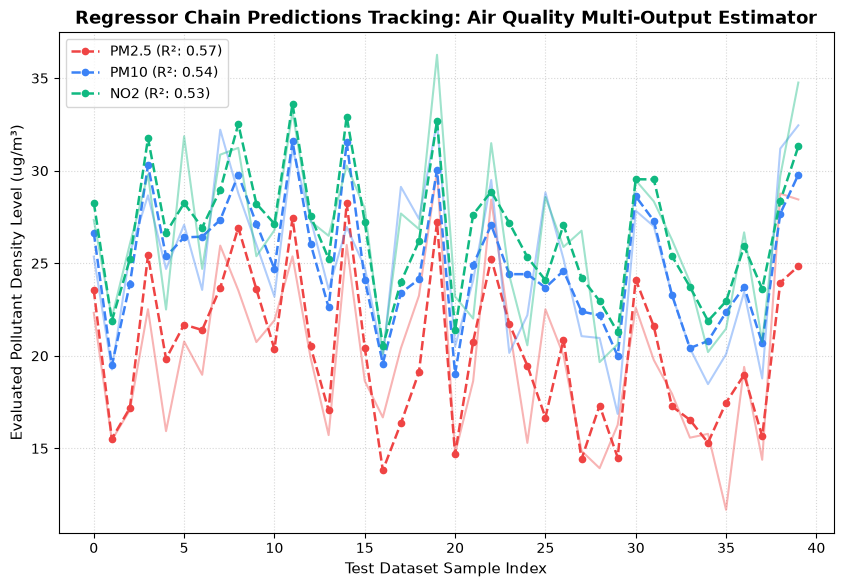

In [3]:
plt.figure(figsize=(10, 6.5))

# Plot actual vs predicted sequences for a subset of samples
plot_samples = 40
x_samples = range(plot_samples)

colors = ['#EF4444', '#3B82F6', '#10B981']
targets_names = ['PM2.5', 'PM10', 'NO2']

for i in range(3):
    # Actual targets (solid lines)
    plt.plot(x_samples, y_test[:plot_samples, i], color=colors[i], linestyle='-', alpha=0.4, linewidth=1.5)
    # Predicted targets (dashed lines with markers)
    plt.plot(
        x_samples, 
        y_pred[:plot_samples, i], 
        color=colors[i], 
        linestyle='--', 
        marker='o', 
        markersize=4.5, 
        label=f'{targets_names[i]} (R²: {r2_scores[i]:.2f})',
        linewidth=1.8
    )

plt.title('Regressor Chain Predictions Tracking: Air Quality Multi-Output Estimator', fontsize=13, fontweight='bold')
plt.xlabel('Test Dataset Sample Index', fontsize=11)
plt.ylabel('Evaluated Pollutant Density Level (ug/m³)', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
